In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el archivo EPH
df = pd.read_csv('usu_individual_T425.txt', sep=';', low_memory=False)

# Vemos el tamaño
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

# Columnas clave que vamos a usar
cols = ['ESTADO', 'CH04', 'CH06', 'REGION', 'NIVEL_ED', 'CAT_OCUP', 'P21', 'PONDERA']
print(df[cols].head())

Filas: 43703 | Columnas: 235
   ESTADO  CH04  CH06  REGION  NIVEL_ED  CAT_OCUP      P21  PONDERA
0       1     1    46      40         6         3  2800000      228
1       1     2    46      40         6         3  2000000      228
2       4     1     8      40         1         0        0      228
3       1     1    55      40         6         2   700000      113
4       1     2    52      40         6         2   700000      113


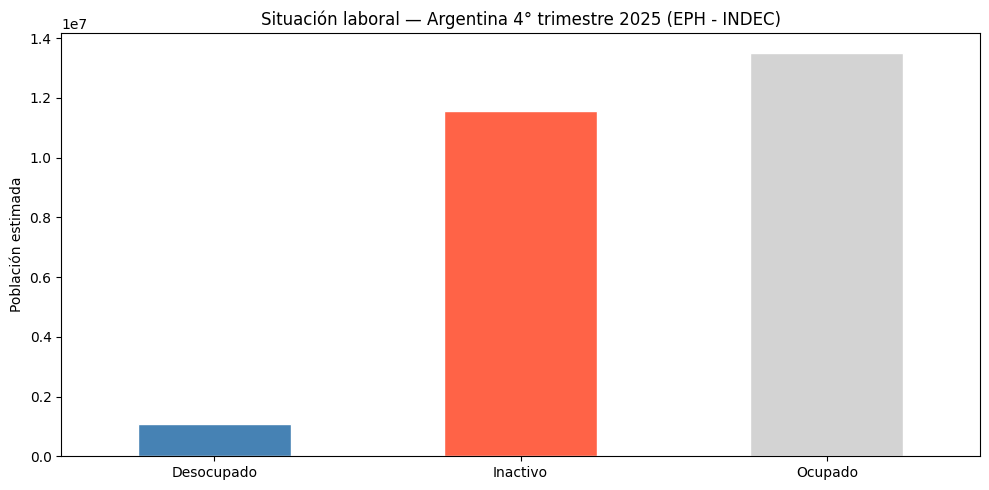

Tasa de desempleo estimada: 7.5%


In [2]:
# Análisis 1: Tasa de desempleo y situación laboral general
# ESTADO: 1=Ocupado, 2=Desocupado, 3=Inactivo, 4=Menor de edad

labels = {1: 'Ocupado', 2: 'Desocupado', 3: 'Inactivo', 4: 'Menor/No aplica'}

situacion = df[df['ESTADO'].isin([1,2,3])].copy()
situacion['ESTADO_LABEL'] = situacion['ESTADO'].map(labels)

conteo = situacion.groupby('ESTADO_LABEL')['PONDERA'].sum()

colores = ['steelblue', 'tomato', 'lightgray']
conteo.plot(kind='bar', figsize=(10,5), color=colores, edgecolor='white')
plt.title('Situación laboral — Argentina 4° trimestre 2025 (EPH - INDEC)')
plt.xlabel('')
plt.ylabel('Población estimada')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculamos tasa de desempleo
ocupados = conteo['Ocupado']
desocupados = conteo['Desocupado']
tasa = desocupados / (ocupados + desocupados) * 100
print(f"Tasa de desempleo estimada: {tasa:.1f}%")

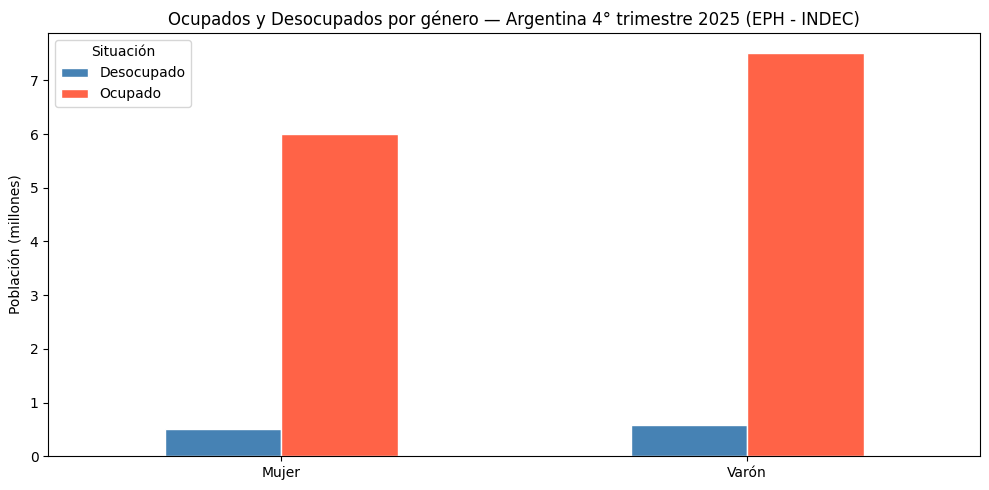

In [3]:
# Análisis 2: Desempleo por género
genero_estado = df[df['ESTADO'].isin([1,2])].copy()
genero_estado['GENERO'] = genero_estado['CH04'].map({1: 'Varón', 2: 'Mujer'})
genero_estado['ESTADO_LABEL'] = genero_estado['ESTADO'].map({1: 'Ocupado', 2: 'Desocupado'})

tabla = genero_estado.groupby(['GENERO', 'ESTADO_LABEL'])['PONDERA'].sum().unstack()
tabla = tabla.div(1_000_000)  # convertimos a millones

tabla.plot(kind='bar', figsize=(10,5), color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Ocupados y Desocupados por género — Argentina 4° trimestre 2025 (EPH - INDEC)')
plt.xlabel('')
plt.ylabel('Población (millones)')
plt.xticks(rotation=0)
plt.legend(title='Situación')
plt.tight_layout()
plt.show()

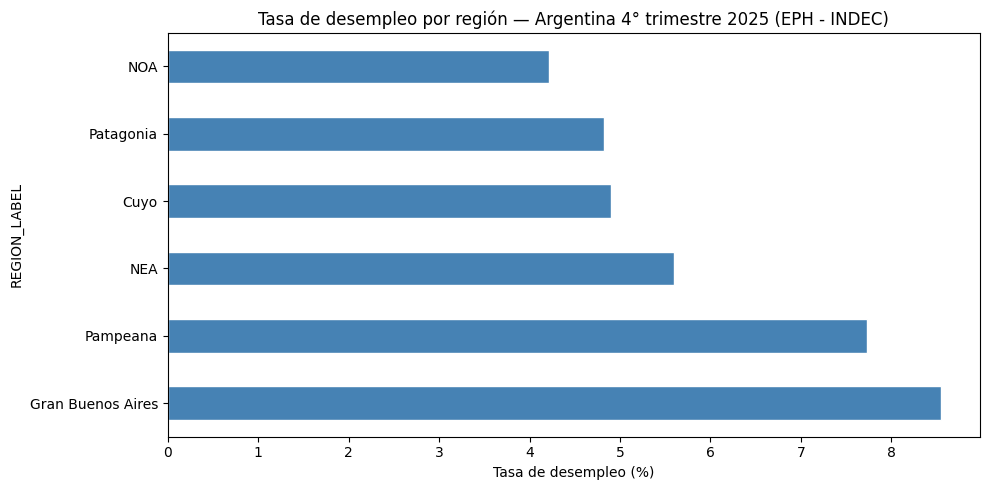

REGION_LABEL
Gran Buenos Aires    8.6
Pampeana             7.7
NEA                  5.6
Cuyo                 4.9
Patagonia            4.8
NOA                  4.2
Name: PONDERA, dtype: float64


In [4]:
# Análisis 3: Desempleo por región
regiones = {
    1: 'Gran Buenos Aires',
    40: 'NOA',
    41: 'NEA',
    42: 'Cuyo',
    43: 'Pampeana',
    44: 'Patagonia'
}

region_estado = df[df['ESTADO'].isin([1,2])].copy()
region_estado['REGION_LABEL'] = region_estado['REGION'].map(regiones)

ocupados_r = region_estado[region_estado['ESTADO']==1].groupby('REGION_LABEL')['PONDERA'].sum()
desocupados_r = region_estado[region_estado['ESTADO']==2].groupby('REGION_LABEL')['PONDERA'].sum()

tasa_region = (desocupados_r / (ocupados_r + desocupados_r) * 100).sort_values(ascending=False)

tasa_region.plot(kind='barh', figsize=(10,5), color='steelblue', edgecolor='white')
plt.title('Tasa de desempleo por región — Argentina 4° trimestre 2025 (EPH - INDEC)')
plt.xlabel('Tasa de desempleo (%)')
plt.tight_layout()
plt.show()

print(tasa_region.round(1))

/tmp/ipykernel_13362/2840626619.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ingreso_genero = ingresos.groupby('GENERO').apply(


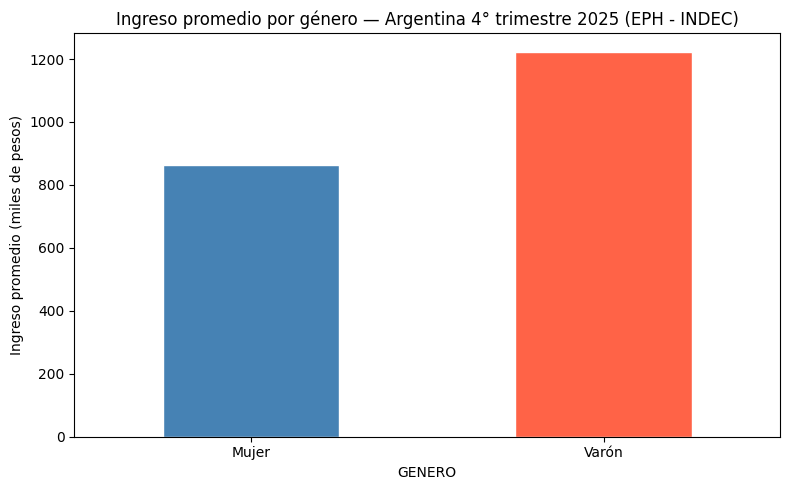

GENERO
Mujer     862.1
Varón    1222.1
dtype: float64


In [5]:
# Análisis 4: Ingreso promedio por género
ingresos = df[(df['ESTADO']==1) & (df['P21']>0)].copy()
ingresos['GENERO'] = ingresos['CH04'].map({1: 'Varón', 2: 'Mujer'})

ingreso_genero = ingresos.groupby('GENERO').apply(
    lambda x: (x['P21'] * x['PONDERA']).sum() / x['PONDERA'].sum()
).div(1000).round(1)

ingreso_genero.plot(kind='bar', figsize=(8,5), color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Ingreso promedio por género — Argentina 4° trimestre 2025 (EPH - INDEC)')
plt.ylabel('Ingreso promedio (miles de pesos)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(ingreso_genero)

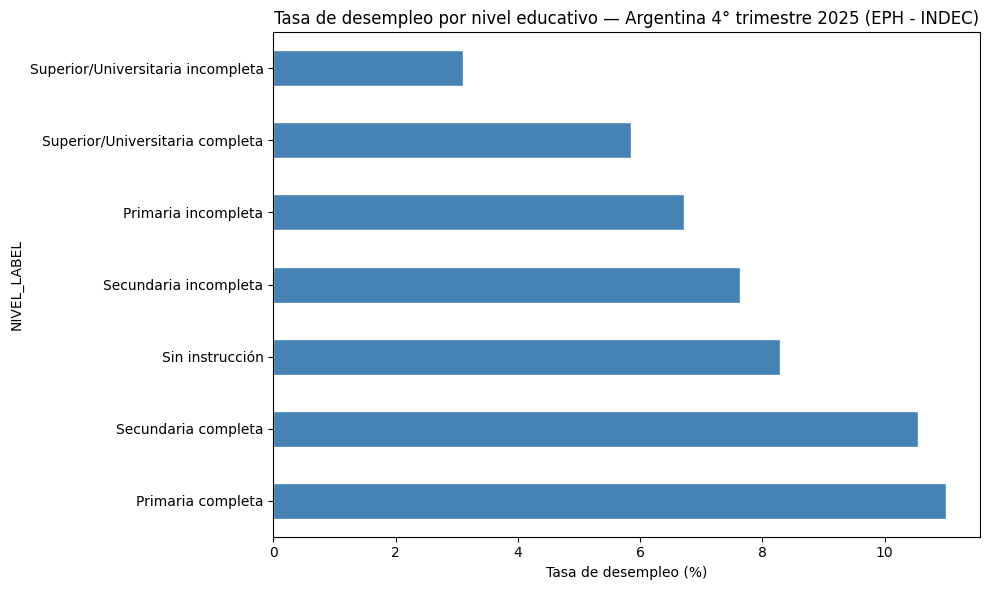

NIVEL_LABEL
Primaria completa                    11.0
Secundaria completa                  10.6
Sin instrucción                       8.3
Secundaria incompleta                 7.6
Primaria incompleta                   6.7
Superior/Universitaria completa       5.8
Superior/Universitaria incompleta     3.1
Name: PONDERA, dtype: float64


In [6]:
# Análisis 5: Tasa de desempleo por nivel educativo
niveles = {
    1: 'Sin instrucción',
    2: 'Primaria incompleta',
    3: 'Primaria completa',
    4: 'Secundaria incompleta',
    5: 'Secundaria completa',
    6: 'Superior/Universitaria incompleta',
    7: 'Superior/Universitaria completa'
}

edu = df[df['ESTADO'].isin([1,2])].copy()
edu['NIVEL_LABEL'] = edu['NIVEL_ED'].map(niveles)
edu = edu.dropna(subset=['NIVEL_LABEL'])

ocupados_e = edu[edu['ESTADO']==1].groupby('NIVEL_LABEL')['PONDERA'].sum()
desocupados_e = edu[edu['ESTADO']==2].groupby('NIVEL_LABEL')['PONDERA'].sum()
tasa_edu = (desocupados_e / (ocupados_e + desocupados_e) * 100).sort_values(ascending=False)

tasa_edu.plot(kind='barh', figsize=(10,6), color='steelblue', edgecolor='white')
plt.title('Tasa de desempleo por nivel educativo — Argentina 4° trimestre 2025 (EPH - INDEC)')
plt.xlabel('Tasa de desempleo (%)')
plt.tight_layout()
plt.show()
print(tasa_edu.round(1))

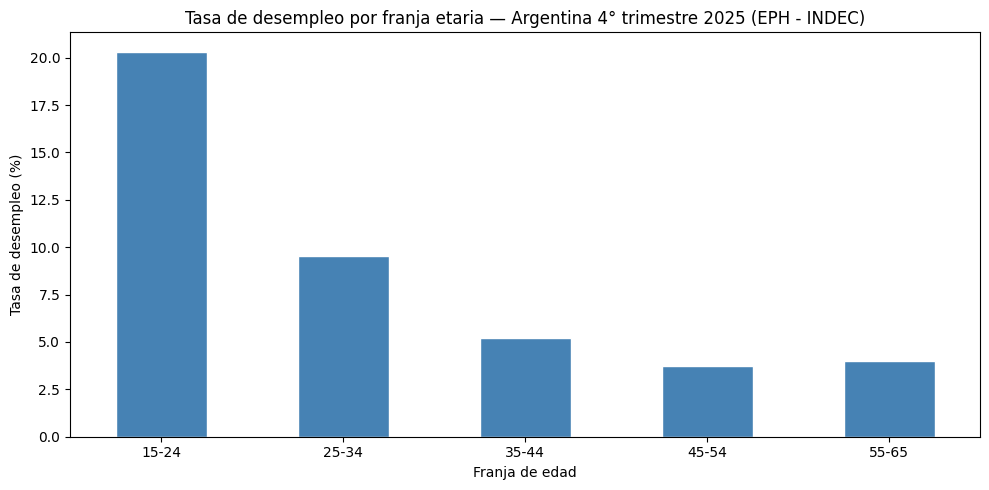

FRANJA
15-24    20.3
25-34     9.5
35-44     5.2
45-54     3.7
55-65     4.0
Name: PONDERA, dtype: float64


In [7]:
# Análisis 6: Desempleo por franja de edad
activos = df[df['ESTADO'].isin([1,2]) & df['CH06'].between(14, 65)].copy()

bins = [14, 24, 34, 44, 54, 65]
labels_edad = ['15-24', '25-34', '35-44', '45-54', '55-65']
activos['FRANJA'] = pd.cut(activos['CH06'], bins=bins, labels=labels_edad)

ocup_edad = activos[activos['ESTADO']==1].groupby('FRANJA', observed=True)['PONDERA'].sum()
desocp_edad = activos[activos['ESTADO']==2].groupby('FRANJA', observed=True)['PONDERA'].sum()
tasa_edad = (desocp_edad / (ocup_edad + desocp_edad) * 100)

tasa_edad.plot(kind='bar', figsize=(10,5), color='steelblue', edgecolor='white')
plt.title('Tasa de desempleo por franja etaria — Argentina 4° trimestre 2025 (EPH - INDEC)')
plt.xlabel('Franja de edad')
plt.ylabel('Tasa de desempleo (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(tasa_edad.round(1))

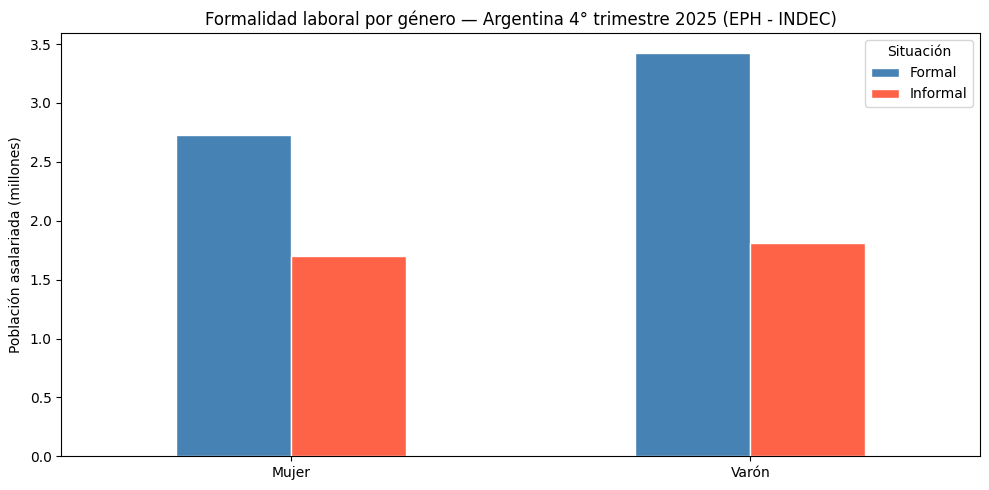

In [8]:
# Análisis 7: Tasa de informalidad por género
# CAT_OCUP: 1=Patrón, 2=Cuenta propia, 3=Asalariado, 4=Trabajador familiar sin remuneración
# PP07H: descuento jubilatorio (1=Sí, 2=No) → proxy de formalidad

informales = df[(df['ESTADO']==1) & (df['CAT_OCUP']==3)].copy()
informales['FORMAL'] = informales['PP07H'].map({1: 'Formal', 2: 'Informal'})
informales['GENERO'] = informales['CH04'].map({1: 'Varón', 2: 'Mujer'})
informales = informales.dropna(subset=['FORMAL'])

tabla_inf = informales.groupby(['GENERO', 'FORMAL'])['PONDERA'].sum().unstack().div(1_000_000)

tabla_inf.plot(kind='bar', figsize=(10,5), color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Formalidad laboral por género — Argentina 4° trimestre 2025 (EPH - INDEC)')
plt.ylabel('Población asalariada (millones)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Situación')
plt.tight_layout()
plt.show()